In [196]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path

from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size, get_utm_epsg_code_from_gps, gps_to_utm_xy
from scene_generation.itu_materials import ITU_MATERIALS

In [197]:
# Scene center
CENTER_LON = -0.126081
CENTER_LAT  = 51.499786 
# -78.940297, 36.002556 (Duke Wilkinson area)
# -74.00361, 40.715 (NYC City Hall area)
# 2.294694, 48.858093 (Eiffel tower area)

SCENE_WIDTH  = 300   # east–west extent, metres
SCENE_HEIGHT = 300   # north–south extent, metres

# rect_from_point_and_size returns a *closed* polygon:
#   [ bottom-left, top-left, top-right, bottom-right, bottom-left ]
# each point is a (longitude, latitude) tuple in WGS84.
scene_polygon = rect_from_point_and_size(
    CENTER_LON, CENTER_LAT, "center", SCENE_WIDTH, SCENE_HEIGHT
)

print(f"Scene center : ({CENTER_LON}°, {CENTER_LAT}°)")
print(f"Dimensions   : {SCENE_WIDTH} m (E–W)  ×  {SCENE_HEIGHT} m (N–S)")
print()
print("Bounding polygon corners (lon, lat):")
corner_labels = ["Bottom-left", "Top-left", "Top-right", "Bottom-right"]
for label, (lon, lat) in zip(corner_labels, scene_polygon):
    print(f"  {label:<14}: ({lon:.6f}°,  {lat:.6f}°)")

Scene center : (-0.126081°, 51.499786°)
Dimensions   : 300 m (E–W)  ×  300 m (N–S)

Bounding polygon corners (lon, lat):
  Bottom-left   : (-0.128324°,  51.498492°)
  Top-left      : (-0.128155°,  51.501186°)
  Top-right     : (-0.123838°,  51.501080°)
  Bottom-right  : (-0.124008°,  51.498386°)


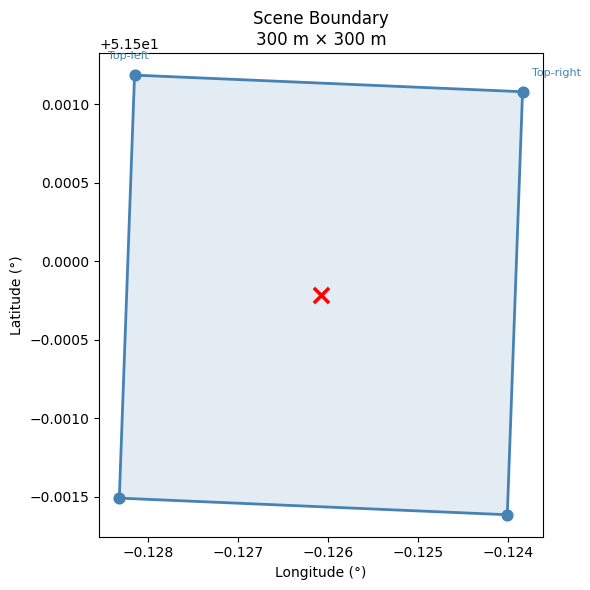

In [198]:
# Visualise the bounding box
lons = [p[0] for p in scene_polygon]
lats = [p[1] for p in scene_polygon]

fig, ax = plt.subplots(figsize=(6, 6))
ax.fill(lons, lats, alpha=0.15, color="steelblue")
ax.plot(lons, lats, color="steelblue", linewidth=2)
ax.scatter(lons[:-1], lats[:-1], color="steelblue", s=60, zorder=5)
ax.scatter([CENTER_LON], [CENTER_LAT], color="red", s=120, zorder=6,
           marker="x", linewidths=2.5, label="Scene center")

offsets = [(-0.0003, -0.0002), (-0.0003, 0.0001), (0.0001, 0.0001), (0.0001, -0.0002)]
for (lon, lat), label, (dx, dy) in zip(scene_polygon[:-1], corner_labels, offsets):
    ax.annotate(label, (lon + dx, lat + dy), fontsize=8, color="steelblue")

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Scene Boundary\n{SCENE_WIDTH} m × {SCENE_HEIGHT} m")
#ax.legend()
plt.tight_layout()
plt.show()

In [199]:
DATA_DIR = "./scenes/big_ben_overture_without_lidar"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(DATA_DIR)}")

Output directory: /home/rt279/working-g2sm/research/examples/scenes/big_ben_overture_without_lidar


In [200]:
scene = Scene()

# Generate the scene using our private OSM server
# If our server is down, please use the public server by changing osm_server_addr to:
# https://overpass-api.de/api/interpreter

building_height_map = scene(
    points=scene_polygon,
    data_dir=DATA_DIR,
    osm_server_addr="http://10.237.198.210:3452/api/interpreter",
    hag_tiff_path=None,                       
    ground_material_type="mat-itu_wet_ground",
    rooftop_material_type="mat-itu_metal",
    wall_material_type="mat-itu_concrete",
    generate_building_map=True,
    # Adding lidar and dem terrain flags
    lidar_height_calibration=False,
    lidar_terrain=False,
    dem_terrain=False,
    building_data_source="overture"
)

print("\nScene generation complete!")

Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Using Overture release: s3://overturemaps-us-west-2/release/2026-06-17.0/theme=buildings/type=building_part/*


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Parsing buildings:   6%|▋         | 56/879 [00:00<00:02, 280.88it/s]

...

building centroid lon=-0.124808 lat=51.499736 height (from bottom to top)=37.00 base height=0.00 height above ground=37.00
building centroid lon=-0.124757 lat=51.499732 height (from bottom to top)=37.00 base height=0.00 height above ground=37.00
building centroid lon=-0.124780 lat=51.499755 height (from bottom to top)=15.00 base height=0.00 height above ground=15.00
building centroid lon=-0.124510 lat=51.499720 height (from bottom to top)=15.00 base height=0.00 height above ground=15.00
building centroid lon=-0.124786 lat=51.499714 height (from bottom to top)=35.00 base height=0.00 height above ground=35.00
building centroid lon=-0.124786 lat=51.499714 height (from bottom to top)=32.00 base height=0.00 height above ground=32.00
building centroid lon=-0.124676 lat=51.499703 height (from bottom to top)=28.00 base height=0.00 height above ground=28.00
building centroid lon=-0.124409 lat=51.499727 height (from bottom to top)=15.00 base height=0.00 height above ground=15.00
building centroi

Parsing buildings:  95%|█████████▍| 834/879 [00:02<00:00, 297.66it/s]

building centroid lon=-0.125632 lat=51.499979 height (from bottom to top)=17.00 base height=0.00 height above ground=17.00
building centroid lon=-0.126930 lat=51.499975 height (from bottom to top)=36.00 base height=0.00 height above ground=36.00
building centroid lon=-0.127040 lat=51.499975 height (from bottom to top)=36.00 base height=0.00 height above ground=36.00
building centroid lon=-0.127042 lat=51.499881 height (from bottom to top)=5.00 base height=0.00 height above ground=5.00
building centroid lon=-0.127191 lat=51.499707 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroid lon=-0.127360 lat=51.499716 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroid lon=-0.127460 lat=51.499722 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroid lon=-0.127489 lat=51.499691 height (from bottom to top)=25.00 base height=0.00 height above ground=25.00
building centroid 

Parsing buildings: 100%|██████████| 879/879 [00:03<00:00, 291.55it/s]


building centroid lon=-0.127733 lat=51.499564 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroid lon=-0.127818 lat=51.499559 height (from bottom to top)=25.00 base height=0.00 height above ground=25.00
building centroid lon=-0.127652 lat=51.499559 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroid lon=-0.127651 lat=51.499566 height (from bottom to top)=10.00 base height=0.00 height above ground=10.00
building centroid lon=-0.127652 lat=51.499563 height (from bottom to top)=15.00 base height=0.00 height above ground=15.00
building centroid lon=-0.127569 lat=51.499561 height (from bottom to top)=10.00 base height=0.00 height above ground=10.00
building centroid lon=-0.127569 lat=51.499558 height (from bottom to top)=15.00 base height=0.00 height above ground=15.00
building centroid lon=-0.127570 lat=51.499555 height (from bottom to top)=20.00 base height=0.00 height above ground=20.00
building centroi

---
## Part 4 — Exploring the Outputs

After generation, the output directory contains:

| File / folder | Description |
|---------------|-------------|
| `scene.xml` | Mitsuba/Sionna scene — materials, geometry references, metadata |
| `2D_Building_Height_Map.npy` | 2D NumPy array; pixel value = building height in metres |
| `mesh/ground.ply` | Triangle mesh for the flat ground plane |
| `mesh/building_N_rooftop.ply` | Top-face mesh for building N |
| `mesh/building_N_wall.ply` | Side-face mesh for building N |

Let's inspect each of these.

In [201]:
# Print directory tree with file sizes
mesh_dir = Path(DATA_DIR) / "mesh"
mesh_files = sorted(mesh_dir.iterdir())

rooftop_files = [f for f in mesh_files if "rooftop" in f.name]
wall_files    = [f for f in mesh_files if "wall"    in f.name]
ground_files  = [f for f in mesh_files if "ground"  in f.name]
n_buildings   = len(rooftop_files)

print(f"{DATA_DIR}/")
for fpath in sorted(Path(DATA_DIR).iterdir()):
    if fpath.is_file():
        kb = fpath.stat().st_size / 1024
        print(f"  {fpath.name:<40} ({kb:>6.1f} KB)")

print(f"  mesh/")
for f in ground_files:
    kb = f.stat().st_size / 1024
    print(f"    {f.name:<38} ({kb:>6.1f} KB)")
if n_buildings > 0:
    last = n_buildings - 1
    print(f"    building_0_rooftop.ply … building_{last}_rooftop.ply  ({n_buildings} files)")
    print(f"    building_0_wall.ply     … building_{last}_wall.ply     ({n_buildings} files)")

total_mb = sum(f.stat().st_size for f in mesh_files) / 1024**2
print()
print(f"Buildings in scene : {n_buildings}")
print(f"Total mesh size    : {total_mb:.2f} MB")

./scenes/big_ben_overture_without_lidar/
  2D_Building_Height_Map.npy               ( 354.0 KB)
  building_centroids_and_heights.csv       ( 108.0 KB)
  scene.xml                                ( 408.8 KB)
  mesh/
    ground.ply                             (   0.3 KB)
    building_0_rooftop.ply … building_878_rooftop.ply  (879 files)
    building_0_wall.ply     … building_878_wall.ply     (879 files)

Buildings in scene : 879
Total mesh size    : 1.12 MB


### Scene metadata in `scene.xml`

Geo2SigMap embeds scene metadata as `<default>` elements at the top of the XML.
This makes the scene self-describing: any tool that reads `scene.xml` can recover
the bounding box, material choices, UTM zone, and version without needing a sidecar file.

In [202]:
# Parse scene.xml and display metadata
tree = ET.parse(os.path.join(DATA_DIR, "scene.xml"))
root = tree.getroot()

meta = {e.get("name"): e.get("value") for e in root.findall("default")}

labels = {
    "scenegen_version":          "Geo2SigMap version",
    "scenegen_create_time":      "Created at",
    "scenegen_UTM_zone":         "UTM projection",
    "scenegen_center_lon":       "Center longitude",
    "scenegen_center_lat":       "Center latitude",
    "scenegen_bbox_width":       "Scene width (m)",
    "scenegen_bbox_length":      "Scene height (m)",
    "scenegen_ground_material":  "Ground material",
    "scenegen_rooftop_material": "Rooftop material",
    "scenegen_wall_material":    "Wall material",
}

print("=== Scene Metadata (from scene.xml) ===\n")
for key, label in labels.items():
    if key in meta:
        print(f"  {label:<26} {meta[key]}")

# Count XML shape elements
shapes          = root.findall("shape")
ground_shapes   = [s for s in shapes if s.get("id") == "mesh-ground"]
building_shapes = [s for s in shapes if "building" in s.get("id", "")]
print(f"\n  Ground mesh shapes    : {len(ground_shapes)}")
print(f"  Building mesh shapes  : {len(building_shapes)}"
      f"  ({len(building_shapes)//2} buildings × 2 surfaces)")

=== Scene Metadata (from scene.xml) ===

  Geo2SigMap version         1.0.0
  Created at                 2026-07-10 06:24:57.529241
  UTM projection             EPSG:32630
  Center longitude           -0.126081
  Center latitude            51.499786
  Scene width (m)            301
  Scene height (m)           301
  Ground material            mat-itu_wet_ground
  Rooftop material           mat-itu_metal
  Wall material              mat-itu_concrete

  Ground mesh shapes    : 1
  Building mesh shapes  : 1758  (879 buildings × 2 surfaces)


---
## Part 5 — The 2D Building Height Map

When `generate_building_map=True`, Geo2SigMap produces a 2D array saved as
`2D_Building_Height_Map.npy`.
Each **pixel corresponds to one square metre** of the scene, and its value is the
building height in metres (0 = open ground).

This map is useful for:
- **Visual sanity-checking** — Does the scene look right? Are buildings where expected?
- **U-Net signal prediction** — The map is an input feature for the ML coverage model
  (covered in a later tutorial)
- **Scene statistics** — Quickly compute building density, height distribution, etc.

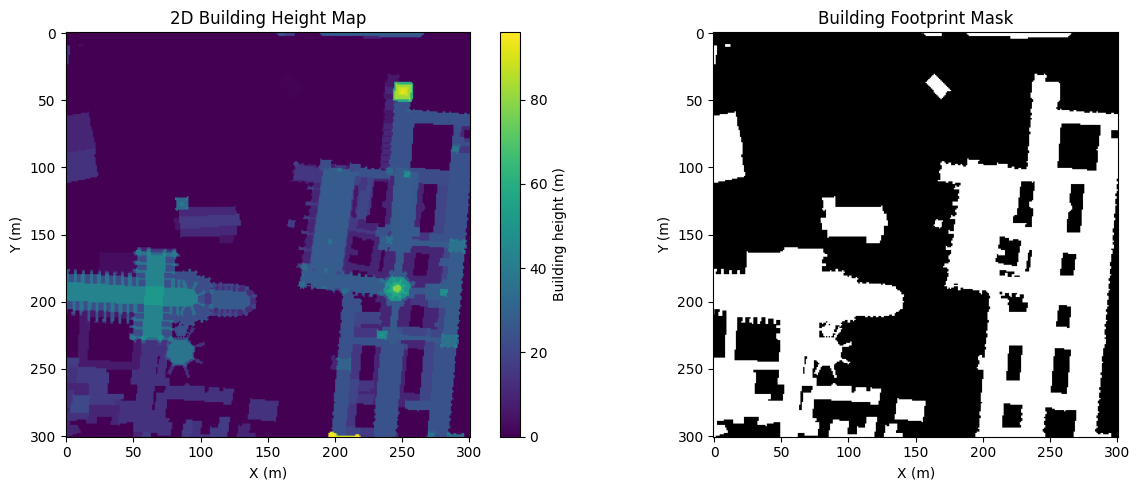

Height map shape   : 301 × 301 pixels (1 px = 1 m²)
Height range       : 1.0 – 96.0 m
Building coverage  : 38.1% of scene area


In [203]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: height values
im = axes[0].imshow(building_height_map, cmap="viridis", origin="upper")
plt.colorbar(im, ax=axes[0], label="Building height (m)")
axes[0].set_title("2D Building Height Map")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")

# Right: binary footprint mask (building vs. open ground)
mask = building_height_map > 0
axes[1].imshow(mask, cmap="gray", origin="upper")
axes[1].set_title("Building Footprint Mask")
axes[1].set_xlabel("X (m)")
axes[1].set_ylabel("Y (m)")

plt.tight_layout()
plt.show()

coverage = 100 * mask.sum() / mask.size
h_vals   = building_height_map[mask]
print(f"Height map shape   : {building_height_map.shape[1]} × {building_height_map.shape[0]} pixels (1 px = 1 m²)")
print(f"Height range       : {h_vals.min():.1f} – {h_vals.max():.1f} m")
print(f"Building coverage  : {coverage:.1f}% of scene area")

## Part 8 — Visualizing `scene.xml`

We use the built-in Sionna helper function to see our completed scene.

In [204]:
from sionna.rt import scene, preview

dc_scene = scene.load_scene(DATA_DIR + "/scene.xml")
dc_scene.preview()

2026-07-10 06:25:26 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
